In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from src.data.loader import load_raw_data
from src.data.preprocessor import clean_text, preprocess_dataframe
from src.utils.config import TEXT_COLUMN, CATEGORY_TARGET, PRIORITY_TARGET

In [2]:
df = load_raw_data()
print(f"Loaded {len(df)} rows")

[2026-04-10 08:00:17] INFO — src.data.loader — Loading dataset from E:\Future ml projects\FUTURE_ML_02\data\raw\customer_support_tickets.csv
[2026-04-10 08:00:17] INFO — src.data.loader — Loaded 8469 rows and 17 columns
Loaded 8469 rows


In [11]:
# Pick a raw ticket and watch it transform step by step
sample_text = df[TEXT_COLUMN].iloc[0]

print("=== ORIGINAL TEXT ===")
print(sample_text)
print(f"\nLength: {len(sample_text)} characters")

print("\n=== CLEANED TEXT ===")
cleaned = clean_text(sample_text)
print(cleaned)
print(f"\nLength: {len(cleaned)} characters")

=== ORIGINAL TEXT ===
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

Length: 284 characters

=== CLEANED TEXT ===
im issue please assist billing zip code appreciate requested website address please double check email address ive tried troubleshooting step mentioned user manual issue persists

Length: 178 characters


In [12]:
from src.data.preprocessor import (
    to_lowercase,
    remove_punctuation,
    remove_numbers,
    remove_extra_whitespace,
    remove_stopwords,
    lemmatize_text
)

text = df[TEXT_COLUMN].iloc[0]

print(f"Original:          {text[:120]}")
text = to_lowercase(text)
print(f"Lowercase:         {text[:120]}")
text = remove_punctuation(text)
print(f"No punctuation:    {text[:120]}")
text = remove_numbers(text)
print(f"No numbers:        {text[:120]}")
text = remove_extra_whitespace(text)
print(f"No extra spaces:   {text[:120]}")
text = remove_stopwords(text)
print(f"No stopwords:      {text[:120]}")
text = lemmatize_text(text)
print(f"Lemmatized:        {text[:120]}")

Original:          I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that y
Lowercase:         i'm having an issue with the {product_purchased}. please assist.

your billing zip code is: 71701.

we appreciate that y
No punctuation:    im having an issue with the productpurchased please assist

your billing zip code is 71701

we appreciate that you have 
No numbers:        im having an issue with the productpurchased please assist

your billing zip code is 

we appreciate that you have reque
No extra spaces:   im having an issue with the productpurchased please assist your billing zip code is we appreciate that you have requeste
No stopwords:      im issue productpurchased please assist billing zip code appreciate requested website address please double check email 
Lemmatized:        im issue productpurchased please assist billing zip code appreciate requested website address please double check email 


In [21]:
df_clean = preprocess_dataframe(df)

print(f"Original rows:  {len(df)}")
print(f"Remaining rows: {len(df_clean)}")
print(f"Rows dropped:   {len(df) - len(df_clean)}")

[2026-04-10 08:53:41] INFO — src.data.preprocessor — Starting text preprocessing pipeline...
[2026-04-10 08:53:41] INFO — src.data.preprocessor — Dropping rows with missing ticket text...
[2026-04-10 08:53:41] INFO — src.data.preprocessor — Cleaning text column...
[2026-04-10 08:53:46] INFO — src.data.preprocessor — Removing rows where clean text is empty after processing...
[2026-04-10 08:53:46] INFO — src.data.preprocessor — Preprocessing complete. 8469 rows remaining.
Original rows:  8469
Remaining rows: 8469
Rows dropped:   0


In [14]:
print("=== 3 TICKET COMPARISON: BEFORE vs AFTER ===\n")

for i in range(3):
    print(f"--- Ticket {i+1} ---")
    print(f"BEFORE: {df[TEXT_COLUMN].iloc[i][:200]}")
    print(f"AFTER:  {df_clean['clean_text'].iloc[i][:200]}")
    print()

=== 3 TICKET COMPARISON: BEFORE vs AFTER ===

--- Ticket 1 ---
BEFORE: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I'
AFTER:  im issue please assist billing zip code appreciate requested website address please double check email address ive tried troubleshooting step mentioned user manual issue persists

--- Ticket 2 ---
BEFORE: I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing 
AFTER:  im issue please assist need change existing product im issue please assist issue im facing intermittent sometimes work fine time act unexpectedly

--- Ticket 3 ---
BEFORE: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but 

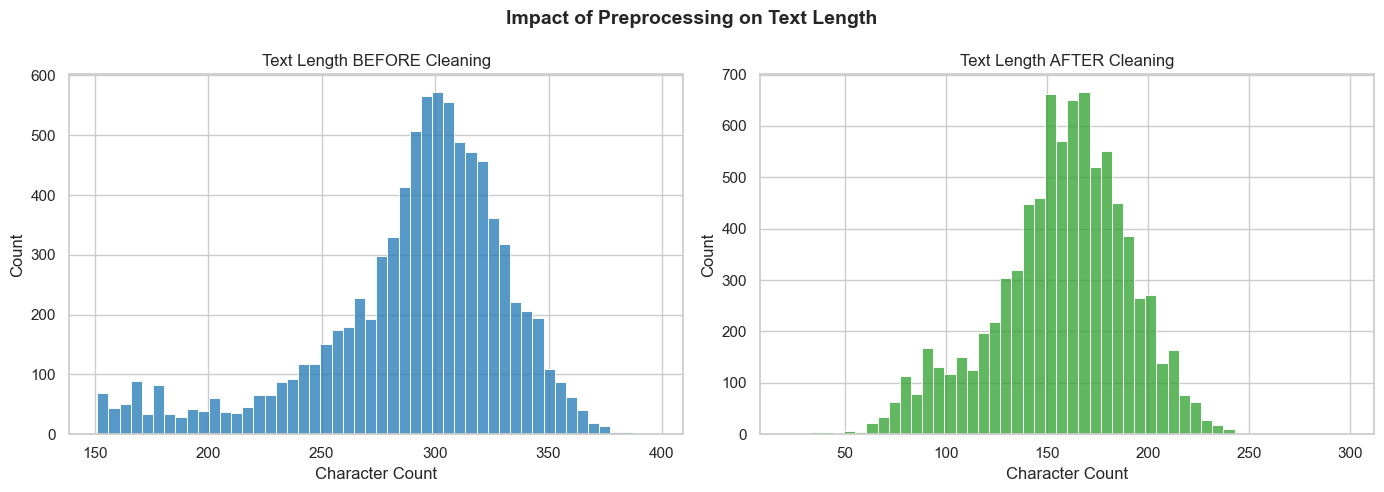

Avg length before: 290 chars
Avg length after:  157 chars
Reduction:         45.9%


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df['text_length'] = df[TEXT_COLUMN].astype(str).apply(len)
df_clean["clean_length"] = df_clean["clean_text"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["text_length"], bins=50, ax=axes[0], color="#1f77b4")
axes[0].set_title("Text Length BEFORE Cleaning")
axes[0].set_xlabel("Character Count")

sns.histplot(df_clean["clean_length"], bins=50, ax=axes[1], color="#2ca02c")
axes[1].set_title("Text Length AFTER Cleaning")
axes[1].set_xlabel("Character Count")

plt.suptitle("Impact of Preprocessing on Text Length", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/text_length_before_after.png", dpi=150)
plt.show()

print(f"Avg length before: {df['text_length'].mean():.0f} chars")
print(f"Avg length after:  {df_clean['clean_length'].mean():.0f} chars")
print(f"Reduction:         {((df['text_length'].mean() - df_clean['clean_length'].mean()) / df['text_length'].mean() * 100):.1f}%")

In [23]:
from src.utils.config import PROCESSED_DATA_DIR

output_path = PROCESSED_DATA_DIR / "tickets_cleaned.csv"

cols_to_save = ["clean_text", CATEGORY_TARGET, PRIORITY_TARGET]
df_clean[cols_to_save].to_csv(output_path, index=False)

print(f"Saved cleaned data to {output_path}")
print(f"Shape: {df_clean[cols_to_save].shape}")

Saved cleaned data to E:\Future ml projects\FUTURE_ML_02\data\processed\tickets_cleaned.csv
Shape: (8469, 3)


In [22]:
# Verify boilerplate is gone
count = df_clean["clean_text"].str.contains("please assist").sum()
print(f"Tickets still containing 'please assist': {count}")

sample = df_clean["clean_text"].iloc[0]
print(f"\nSample clean ticket:\n{sample}")

Tickets still containing 'please assist': 5869

Sample clean ticket:
im issue please assist billing zip code appreciate requested website address please double check email address ive tried troubleshooting step mentioned user manual issue persists
